In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import torch
from clawpack import pyclaw, riemann
from context_flux_no.gaussian_random_field import (
    GaussianCov,
    generate_circulant_embedding_method_1d,
)


jax.config.update("jax_enable_x64", True)

INFO:2025-06-29 02:17:04,979:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


2025-06-29 02:17:04,979 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [2]:
solver = pyclaw.ClawSolver1D(riemann.shallow_hlle_1D)
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

In [3]:
solver.num_eqn

2

In [4]:
domain = pyclaw.Domain([0.0], [1.0], [256])
solution = pyclaw.Solution(solver.num_eqn, domain)


In [5]:
state = solution.state
grid_x = state.grid.p_centers[0]
state.q[0, :] = (
    0.02
    * generate_circulant_embedding_method_1d(
        len(grid_x), grid_x[1] - grid_x[0], GaussianCov(0.1), key=jax.random.PRNGKey(0)
    )
    + 0.5
)
state.q[1, :] = 0.1 * generate_circulant_embedding_method_1d(
    len(grid_x), grid_x[1] - grid_x[0], GaussianCov(0.1), key=jax.random.PRNGKey(10)
)
state.problem_data["grav"] = 9.8

In [ ]:
controller = pyclaw.Controller()
controller.solver = solver
controller.solution = solution
controller.tfinal = 0.5
controller.num_output_times = 2560
controller.keep_copy = True

NameError: name 'pyclaw' is not defined

In [7]:
status = controller.run()

2025-06-29 02:17:11,354 INFO CLAW: Solution 0 computed for time t=0.000000
2025-06-29 02:17:11,361 INFO CLAW: Solution 1 computed for time t=0.000195
2025-06-29 02:17:11,368 INFO CLAW: Solution 2 computed for time t=0.000391
2025-06-29 02:17:11,376 INFO CLAW: Solution 3 computed for time t=0.000586
2025-06-29 02:17:11,382 INFO CLAW: Solution 4 computed for time t=0.000781
2025-06-29 02:17:11,391 INFO CLAW: Solution 5 computed for time t=0.000977
2025-06-29 02:17:11,398 INFO CLAW: Solution 6 computed for time t=0.001172
2025-06-29 02:17:11,407 INFO CLAW: Solution 7 computed for time t=0.001367
2025-06-29 02:17:11,413 INFO CLAW: Solution 8 computed for time t=0.001563
2025-06-29 02:17:11,419 INFO CLAW: Solution 9 computed for time t=0.001758
2025-06-29 02:17:11,425 INFO CLAW: Solution 10 computed for time t=0.001953
2025-06-29 02:17:11,431 INFO CLAW: Solution 11 computed for time t=0.002148
2025-06-29 02:17:11,438 INFO CLAW: Solution 12 computed for time t=0.002344
2025-06-29 02:17:11,44

2025-06-29 02:17:11,450 INFO CLAW: Solution 14 computed for time t=0.002734
2025-06-29 02:17:11,459 INFO CLAW: Solution 15 computed for time t=0.002930
2025-06-29 02:17:11,466 INFO CLAW: Solution 16 computed for time t=0.003125
2025-06-29 02:17:11,474 INFO CLAW: Solution 17 computed for time t=0.003320
2025-06-29 02:17:11,483 INFO CLAW: Solution 18 computed for time t=0.003516
2025-06-29 02:17:11,491 INFO CLAW: Solution 19 computed for time t=0.003711
2025-06-29 02:17:11,500 INFO CLAW: Solution 20 computed for time t=0.003906
2025-06-29 02:17:11,508 INFO CLAW: Solution 21 computed for time t=0.004102
2025-06-29 02:17:11,517 INFO CLAW: Solution 22 computed for time t=0.004297
2025-06-29 02:17:11,525 INFO CLAW: Solution 23 computed for time t=0.004492
2025-06-29 02:17:11,533 INFO CLAW: Solution 24 computed for time t=0.004688
2025-06-29 02:17:11,542 INFO CLAW: Solution 25 computed for time t=0.004883
2025-06-29 02:17:11,549 INFO CLAW: Solution 26 computed for time t=0.005078
2025-06-29 0

In [14]:
controller.frames[0].state.q

array([[ 0.51833405,  0.51963275,  0.52089776,  0.5221342 ,  0.52334664,
         0.52453874,  0.52571286,  0.52686985,  0.52800876,  0.52912678,
         0.53021911,  0.53127906,  0.53229809,  0.53326604,  0.53417139,
         0.53500153,  0.53574318,  0.53638276,  0.53690686,  0.53730261,
         0.5375582 ,  0.53766326,  0.53760924,  0.53738981,  0.53700114,
         0.53644213,  0.53571463,  0.5348235 ,  0.53377668,  0.53258507,
         0.53126246,  0.52982526,  0.5282922 ,  0.52668398,  0.52502283,
         0.52333201,  0.5216353 ,  0.51995643,  0.51831857,  0.51674374,
         0.51525229,  0.51386247,  0.51258999,  0.51144765,  0.51044513,
         0.50958879,  0.50888159,  0.50832313,  0.50790975,  0.50763469,
         0.50748842,  0.50745889,  0.50753197,  0.50769181,  0.50792125,
         0.50820229,  0.50851643,  0.50884506,  0.50916985,  0.50947295,
         0.50973732,  0.50994689,  0.51008673,  0.51014315,  0.51010377,
         0.50995758,  0.50969495,  0.50930767,  0.5

In [16]:
q_array = np.stack([f.state.q for f in controller.frames], axis=0)
q_array.shape

(2561, 2, 256)

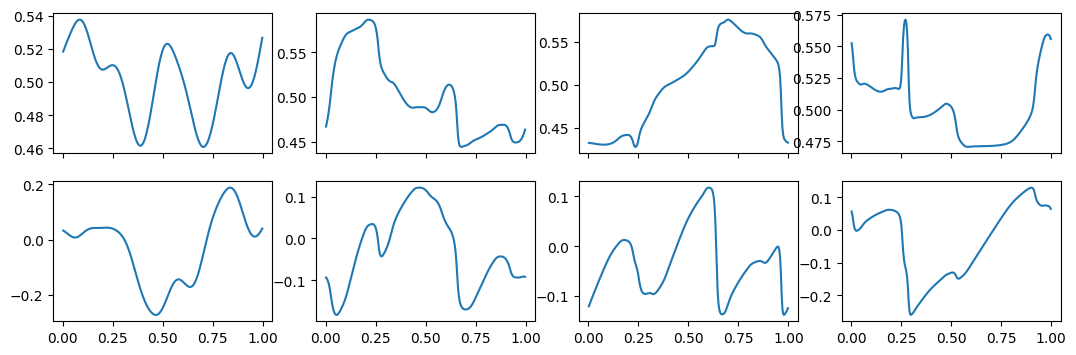

In [20]:
t_vals = (0, 800, 1600, 2400)
fig, axes = plt.subplots(2, 4, figsize=(13, 4), sharex=True)
for i in range(axes.shape[0]):
    for j, t_i in enumerate(t_vals):
        axes[i, j].plot(grid_x, q_array[t_i, i])